# OM convergence

This notebook samples two Markov chain models, generates incremental sequence pairs (X_k, Y_k), computes OM distances in parallel, and plots d_k vs k.

Notes:
- OM distances are normalized by max length.
- Substitution costs are derived from the full-length sequences (X_n, Y_n).


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from joblib import Parallel, delayed
from contextlib import contextmanager

try:
    from numba import njit, prange
except Exception:
    print("Warning: numba not available, falling back to pure Python.")

    def njit(*args, **kwargs):
        def deco(fn):
            return fn
        return deco

    def prange(x):
        return range(x)


c:\Users\Ottavio KHALIFA\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Markov model sampling


In [2]:
def _expand_dirichlet_alpha(alpha, n_rows, n_cols, name="alpha"):
    if np.isscalar(alpha):
        if alpha <= 0:
            raise ValueError(f"{name} must be > 0")
        return np.full((n_rows, n_cols), float(alpha))
    arr = np.asarray(alpha, dtype=float)
    if arr.ndim == 1:
        if arr.shape[0] != n_cols:
            raise ValueError(f"{name} must have length {n_cols}")
        if np.any(arr <= 0):
            raise ValueError(f"All values of {name} must be > 0")
        return np.tile(arr, (n_rows, 1))
    if arr.ndim == 2:
        if arr.shape != (n_rows, n_cols):
            raise ValueError(f"{name} must have shape ({n_rows}, {n_cols})")
        if np.any(arr <= 0):
            raise ValueError(f"All values of {name} must be > 0")
        return arr
    raise ValueError(f"{name} must be a scalar, 1D, or 2D array")


def _expand_dirichlet_alpha_context(alpha, n_contexts, name="alpha_init"):
    if np.isscalar(alpha):
        if alpha <= 0:
            raise ValueError(f"{name} must be > 0")
        return np.full(n_contexts, float(alpha))
    arr = np.asarray(alpha, dtype=float).reshape(-1)
    if arr.shape[0] != n_contexts:
        raise ValueError(f"{name} must have length {n_contexts}")
    if np.any(arr <= 0):
        raise ValueError(f"All values of {name} must be > 0")
    return arr


def _context_to_index(context, n_states):
    idx = 0
    for s in context:
        idx = idx * n_states + int(s)
    return idx


def _index_to_context(idx, n_states, order):
    context = [0] * order
    for pos in range(order - 1, -1, -1):
        context[pos] = int(idx % n_states)
        idx //= n_states
    return context


def sample_markov_model(n_states, order_k, alpha, rng, alpha_init=None):
    if order_k < 1:
        raise ValueError("order_k must be >= 1")
    if n_states < 2:
        raise ValueError("n_states must be >= 2")
    n_contexts = n_states ** order_k
    trans_alpha = _expand_dirichlet_alpha(alpha, n_contexts, n_states, name="alpha")
    transitions = np.empty((n_contexts, n_states), dtype=float)
    for i in range(n_contexts):
        transitions[i] = rng.dirichlet(trans_alpha[i])
    if alpha_init is None:
        alpha_init = alpha
    if order_k == 1:
        init_alpha = _expand_dirichlet_alpha(alpha_init, 1, n_states, name="alpha_init")[0]
        init_probs = rng.dirichlet(init_alpha)
    else:
        init_alpha = _expand_dirichlet_alpha_context(alpha_init, n_contexts, name="alpha_init")
        init_probs = rng.dirichlet(init_alpha)
    return {
        "n_states": n_states,
        "order": order_k,
        "transitions": transitions,
        "init_probs": init_probs,
    }


def sample_two_markov_models(
    n_states,
    order_k,
    alpha,
    seed=None,
    rng=None,
    alpha_init=None,
    same_model=False,
):
    if rng is None:
        rng = np.random.default_rng(seed)
    model_a = sample_markov_model(n_states, order_k, alpha, rng, alpha_init=alpha_init)
    if same_model:
        model_b = {
            "n_states": model_a["n_states"],
            "order": model_a["order"],
            "transitions": np.array(model_a["transitions"], copy=True),
            "init_probs": np.array(model_a["init_probs"], copy=True),
        }
    else:
        model_b = sample_markov_model(n_states, order_k, alpha, rng, alpha_init=alpha_init)
    return model_a, model_b


def _sample_initial_context(model, rng):
    order = model["order"]
    n_states = model["n_states"]
    p = model["init_probs"]
    if order == 1:
        state = int(rng.choice(n_states, p=p))
        return [state]
    idx = int(rng.choice(p.size, p=p))
    return _index_to_context(idx, n_states, order)


def _sample_next_state(model, context, rng):
    idx = _context_to_index(context, model["n_states"])
    probs = model["transitions"][idx]
    return int(rng.choice(model["n_states"], p=probs))


def generate_incremental_pairs(model_x, model_y, n, rng):
    if n <= 0:
        raise ValueError("n must be > 0")
    if model_x["order"] != model_y["order"]:
        raise ValueError("Both models must have the same order_k")
    if model_x["n_states"] != model_y["n_states"]:
        raise ValueError("Both models must have the same n_states")
    order = model_x["order"]
    x_seq = _sample_initial_context(model_x, rng)
    y_seq = _sample_initial_context(model_y, rng)
    pairs = []
    max_init = min(n, order)
    for k in range(1, max_init + 1):
        pairs.append(
            (np.array(x_seq[:k], dtype=np.int64), np.array(y_seq[:k], dtype=np.int64))
        )
    if n <= order:
        return pairs
    x_context = x_seq[-order:]
    y_context = y_seq[-order:]
    for t in range(order, n):
        x_next = _sample_next_state(model_x, x_context, rng)
        y_next = _sample_next_state(model_y, y_context, rng)
        x_seq.append(x_next)
        y_seq.append(y_next)
        x_context = x_seq[-order:]
        y_context = y_seq[-order:]
        pairs.append(
            (np.array(x_seq[: t + 1], dtype=np.int64), np.array(y_seq[: t + 1], dtype=np.int64))
        )
    return pairs


## OM distance (Numba parallel)


In [3]:
# Adapted from CTSTransformer/codex/BENCHARNUMBA/om_distance.py

def compute_trate_subst_matrix(sequences, n_states=None, pad_value=None, smoothing=1e-8):
    if n_states is None:
        max_val = 0
        for seq in sequences:
            if len(seq) > 0:
                max_val = max(max_val, int(np.max(seq)))
        n_states = max_val + 1
    counts = np.zeros((n_states, n_states), dtype=float)
    for seq in sequences:
        arr = np.asarray(seq, dtype=np.int64).reshape(-1)
        if pad_value is not None:
            arr = arr[arr != pad_value]
        if arr.size >= 2:
            p = arr[:-1]
            n = arr[1:]
            idx = p * n_states + n
            counts += np.bincount(idx, minlength=n_states * n_states).reshape(n_states, n_states)
    row_sums = counts.sum(axis=1, keepdims=True)
    P = (counts + smoothing) / (row_sums + smoothing * n_states)
    S = 2.0 - P - P.T
    np.fill_diagonal(S, 0.0)
    return S


def compute_constant_subst_matrix(n_states, cost=1.0):
    if n_states is None or n_states < 2:
        raise ValueError("n_states must be >= 2")
    S = np.full((n_states, n_states), float(cost))
    np.fill_diagonal(S, 0.0)
    return S


def compute_random_subst_matrix(n_states, rng, low=0.5, high=2.0):
    if n_states is None or n_states < 2:
        raise ValueError("n_states must be >= 2")
    if low <= 0 or high <= 0 or high <= low:
        raise ValueError("low and high must be > 0 with high > low")
    M = rng.uniform(low, high, size=(n_states, n_states))
    S = 0.5 * (M + M.T)
    np.fill_diagonal(S, 0.0)
    return S


def choose_indel_cost(subst_cost, strategy="median_nonzero"):
    C = subst_cost.shape[0]
    offdiag = subst_cost[~np.eye(C, dtype=bool)]
    offdiag = offdiag[offdiag > 0]
    if offdiag.size == 0:
        return 1.0
    if strategy == "mean_nonzero":
        return float(offdiag.mean())
    return float(np.median(offdiag))


@njit(fastmath=True)
def _om_distance_univariate_numba(A, B, subst_cost, indel_cost):
    n = A.shape[0]
    m = B.shape[0]
    dp = np.empty((n + 1, m + 1), dtype=np.float64)
    dp[0, 0] = 0.0
    for i in range(1, n + 1):
        dp[i, 0] = dp[i - 1, 0] + indel_cost
    for j in range(1, m + 1):
        dp[0, j] = dp[0, j - 1] + indel_cost
    for i in range(1, n + 1):
        ai = A[i - 1]
        for j in range(1, m + 1):
            bj = B[j - 1]
            d_del = dp[i - 1, j] + indel_cost
            d_ins = dp[i, j - 1] + indel_cost
            d_sub = dp[i - 1, j - 1] + subst_cost[ai, bj]
            best = d_del if d_del < d_ins else d_ins
            if d_sub < best:
                best = d_sub
            dp[i, j] = best
    return dp[n, m]


@njit(fastmath=True, parallel=True)
def om_distances_pairs_numba(X_pad, X_len, Y_pad, Y_len, subst_cost, indel_cost, normalize_by_length):
    N = X_pad.shape[0]
    out = np.zeros(N, dtype=np.float64)
    for i in prange(N):
        Li = X_len[i]
        Lj = Y_len[i]
        A = X_pad[i, :Li]
        B = Y_pad[i, :Lj]
        d = _om_distance_univariate_numba(A, B, subst_cost, indel_cost)
        if normalize_by_length:
            L = Li if Li >= Lj else Lj
            if L > 0:
                d = d / L
        out[i] = d
    return out


def _pad_sequences(sequences, pad_value=-1):
    lengths = np.array([len(s) for s in sequences], dtype=np.int64)
    if lengths.size == 0:
        raise ValueError("No sequences provided")
    Lmax = int(lengths.max())
    X = np.full((len(sequences), Lmax), pad_value, dtype=np.int64)
    for i, seq in enumerate(sequences):
        X[i, :len(seq)] = seq
    return X, lengths


def compute_om_distances_parallel(X_list, Y_list, subst_cost, indel_cost, normalize_by_length=True):
    if len(X_list) != len(Y_list):
        raise ValueError("X_list and Y_list must have the same length")
    X_pad, X_len = _pad_sequences(X_list)
    Y_pad, Y_len = _pad_sequences(Y_list)
    return om_distances_pairs_numba(
        X_pad, X_len, Y_pad, Y_len, subst_cost, float(indel_cost), normalize_by_length
    )


## Pipeline: generate pairs and distances


In [4]:
def generate_pairs_and_distances(
    n_states,
    order_k,
    alpha,
    n,
    seed=None,
    rng=None,
    alpha_init=None,
    smoothing=1e-8,
    indel_strategy="median_nonzero",
    normalize_by_length=True,
    subst_method="trate",
    constant_cost=1.0,
    random_cost_low=0.5,
    random_cost_high=2.0,
    same_model=False,
):
    if rng is None:
        rng = np.random.default_rng(seed)
    model_x, model_y = sample_two_markov_models(
        n_states,
        order_k,
        alpha,
        rng=rng,
        alpha_init=alpha_init,
        same_model=same_model,
    )
    pairs = generate_incremental_pairs(model_x, model_y, n, rng)
    X_list = [p[0] for p in pairs]
    Y_list = [p[1] for p in pairs]
    if subst_method == "trate":
        subst_cost = compute_trate_subst_matrix(
            [X_list[-1], Y_list[-1]], n_states=n_states, smoothing=smoothing
        )
        indel_cost = choose_indel_cost(subst_cost, strategy=indel_strategy)
    elif subst_method == "constant":
        subst_cost = compute_constant_subst_matrix(n_states, cost=constant_cost)
        indel_cost = float(constant_cost)
    elif subst_method == "random":
        subst_cost = compute_random_subst_matrix(
            n_states, rng, low=random_cost_low, high=random_cost_high
        )
        indel_cost = choose_indel_cost(subst_cost, strategy=indel_strategy)
    else:
        raise ValueError("subst_method must be 'trate', 'constant', or 'random'")
    distances = compute_om_distances_parallel(
        X_list,
        Y_list,
        subst_cost,
        indel_cost,
        normalize_by_length=normalize_by_length,
    )
    return {
        "model_x": model_x,
        "model_y": model_y,
        "pairs": pairs,
        "X_list": X_list,
        "Y_list": Y_list,
        "subst_cost": subst_cost,
        "indel_cost": indel_cost,
        "distances": distances,
    }


In [5]:
try:
    from scipy.optimize import linprog
    SCIPY_OK = True
except Exception:
    SCIPY_OK = False


def build_context_transition_matrix(model):
    n_states = model["n_states"]
    order_k = model["order"]
    if order_k <= 1:
        raise ValueError("order_k must be > 1 for context transition matrix")
    n_contexts = n_states ** order_k
    Q = np.zeros((n_contexts, n_contexts), dtype=float)
    for i in range(n_contexts):
        ctx = _index_to_context(i, n_states, order_k)
        probs = model["transitions"][i]
        for a in range(n_states):
            p = probs[a]
            if p == 0:
                continue
            ctx_next = ctx[1:] + [a]
            j = _context_to_index(ctx_next, n_states)
            Q[i, j] += p
    return Q


def stationary_distribution_markov(P, init=None, tol=1e-12, max_iter=200000):
    n = P.shape[0]
    if init is None:
        v = np.full(n, 1.0 / n)
    else:
        v = np.asarray(init, dtype=float).reshape(-1)
        if v.size != n:
            raise ValueError("init must have length matching P")
        s = v.sum()
        if s <= 0:
            raise ValueError("init must sum to > 0")
        v = v / s
    for _ in range(max_iter):
        v_next = v @ P
        if np.abs(v_next - v).sum() < tol:
            v = v_next
            break
        v = v_next
    s = v.sum()
    if s > 0:
        v = v / s
    return v


def stationary_symbol_distribution(model):
    n_states = model["n_states"]
    order_k = model["order"]
    if order_k == 1:
        P = model["transitions"]
        return stationary_distribution_markov(P)
    Q = build_context_transition_matrix(model)
    pi_ctx = stationary_distribution_markov(Q, init=model.get("init_probs"))
    pi_sym = np.zeros(n_states, dtype=float)
    for idx in range(Q.shape[0]):
        ctx = _index_to_context(idx, n_states, order_k)
        pi_sym[ctx[-1]] += pi_ctx[idx]
    s = pi_sym.sum()
    if s > 0:
        pi_sym = pi_sym / s
    return pi_sym


def wasserstein_p_cost_lp(p, q, C, p_wasserstein=1.0):
    p = np.asarray(p, dtype=float).reshape(-1)
    q = np.asarray(q, dtype=float).reshape(-1)
    if p_wasserstein <= 0:
        raise ValueError("p_wasserstein must be > 0")
    n = p.size
    if C.shape != (n, n):
        raise ValueError("C must be square with size matching p and q")
    p_sum = p.sum()
    q_sum = q.sum()
    if p_sum <= 0 or q_sum <= 0:
        raise ValueError("p and q must sum to > 0")
    p = p / p_sum
    q = q / q_sum
    C_p = C ** p_wasserstein
    if SCIPY_OK:
        c = C_p.reshape(-1)
        A_eq = np.zeros((2 * n, n * n), dtype=float)
        b_eq = np.concatenate([p, q])
        for i in range(n):
            A_eq[i, i * n : (i + 1) * n] = 1.0
        for j in range(n):
            A_eq[n + j, j::n] = 1.0
        bounds = [(0.0, None)] * (n * n)
        res = linprog(c, A_eq=A_eq, b_eq=b_eq, bounds=bounds, method="highs")
        if res.success:
            return float(res.fun) ** (1.0 / p_wasserstein)
    eps = 1e-2
    K = np.exp(-C_p / eps)
    K = np.maximum(K, 1e-300)
    u = np.ones(n, dtype=float)
    v = np.ones(n, dtype=float)
    for _ in range(10000):
        Ku = K @ v
        Ku = np.maximum(Ku, 1e-300)
        u = p / Ku
        KTu = K.T @ u
        KTu = np.maximum(KTu, 1e-300)
        v = q / KTu
    Gamma = (u[:, None] * K) * v[None, :]
    return float(np.sum(Gamma * C_p)) ** (1.0 / p_wasserstein)


## Run experiment


In [6]:
n_states = 15
order_k = 2
alpha = 0.5
n = 1000
seed = 123
subst_method = "trate"  # "trate", "constant", or "random"
constant_cost = 1.0
random_cost_low = 0.3
random_cost_high = 0.5
same_model = False
p_wasserstein = 1

result = generate_pairs_and_distances(
    n_states=n_states,
    order_k=order_k,
    alpha=alpha,
    n=n,
    seed=seed,
    subst_method=subst_method,
    constant_cost=constant_cost,
    random_cost_low=random_cost_low,
    random_cost_high=random_cost_high,
    same_model=same_model,
)

model_x = result["model_x"]
model_y = result["model_y"]
subst_cost = result["subst_cost"]

pi_X = stationary_symbol_distribution(model_x)
pi_Y = stationary_symbol_distribution(model_y)
W = wasserstein_p_cost_lp(pi_X, pi_Y, subst_cost, p_wasserstein=p_wasserstein)
S_inf = float(np.max(subst_cost))
overlap = float(pi_X @ pi_Y)
UB = S_inf * (1.0 - overlap)

print("pi_X.sum()", pi_X.sum(), "pi_Y.sum()", pi_Y.sum())
print("p", p_wasserstein, "W", W, "UB", UB, "S_inf", S_inf, "overlap", overlap)

distances = result["distances"]
k_vals = np.arange(1, n + 1)


pi_X.sum() 1.0 pi_Y.sum() 1.0
p 1 W 0.07828774397862537 UB 1.825101775589397 S_inf 1.955882352834572 overlap 0.0668652575425309


## Plot


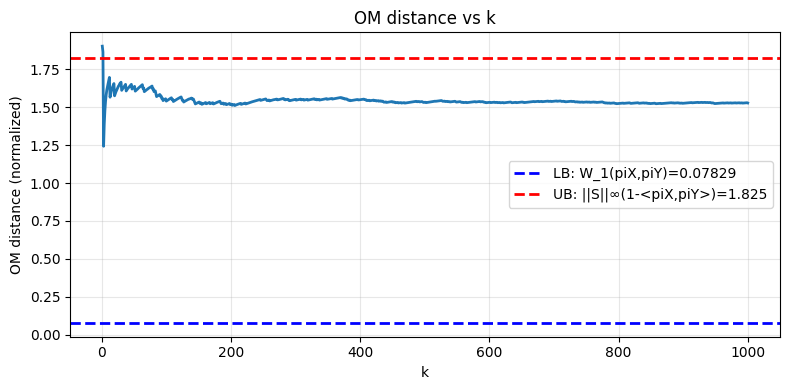

In [7]:
plt.figure(figsize=(8, 4))
plt.plot(k_vals, distances, lw=2)
plt.axhline(W, lw=2, ls="--", label=f"LB: W_{p_wasserstein}(piX,piY)={W:.4g}", color = "blue")
plt.axhline(UB, lw=2, ls="--", label=f"UB: ||S||∞(1-<piX,piY>)={UB:.4g}", color = "red")
plt.xlabel("k")
plt.ylabel("OM distance (normalized)")
plt.title("OM distance vs k")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


### Estimation de gamma et vérification des hypothèses


In [8]:
import numpy as np

def simulate_markov_sequence(model, n, rng):
    """
    Utilise _sample_initial_context et _sample_next_state du notebook.
    """
    order = model["order"]
    context = list(_sample_initial_context(model, rng))
    seq = list(context)
    while len(seq) < n:
        x_next = _sample_next_state(model, seq[-order:], rng)
        seq.append(int(x_next))
    return np.asarray(seq[:n], dtype=np.int64)


def estimate_gamma_by_prefix_convergence(
    model_a,
    model_b,
    subst_cost,
    indel_cost,
    n_max=2000,
    check_every=100,
    window=5,
    delta=1e-3,
    seed_a=0,
    seed_b=1,
):
    """
    Estime gamma(model_a, model_b) via D_n/n qui se stabilise.
    """
    rng_a = np.random.default_rng(seed_a)
    rng_b = np.random.default_rng(seed_b)

    x = simulate_markov_sequence(model_a, n_max, rng_a)
    y = simulate_markov_sequence(model_b, n_max, rng_b)

    n_vals, D_vals, D_over_n = [], [], []

    for n in range(check_every, n_max + 1, check_every):
        Dn = _om_distance_univariate_numba(x[:n], y[:n], subst_cost, float(indel_cost))
        n_vals.append(n)
        D_vals.append(float(Dn))
        D_over_n.append(float(Dn) / float(n))

        if len(D_over_n) >= window:
            recent = D_over_n[-window:]
            if (max(recent) - min(recent)) <= delta:
                break

    return D_over_n[-1], {
        "n_vals": np.asarray(n_vals, dtype=int),
        "D_vals": np.asarray(D_vals, dtype=float),
        "D_over_n": np.asarray(D_over_n, dtype=float),
        "stopped_early": (n_vals[-1] < n_max),
    }


In [9]:
def run_one_experiment_check_hypotheses(
    K=5,
    n_states=15,
    order_k=2,
    alpha=1.0,
    # estimation gamma
    n_max=2000,
    check_every=100,
    window=5,
    delta=1e-3,
    # coûts
    subst_method="constant",   # "constant" ou "random" ou "trate"
    cost=1.0,                  # <-- nom "cost" comme dans le notebook
    indel_strategy="median_nonzero",
    # séparation/balance
    w_ratio=2.0,               # w_max / w_min
    base_seed=123,
    verbose=False,
):
    rng = np.random.default_rng(base_seed)

    # 1) Génération des K modèles
    models = []
    for k in range(K):
        models.append(
            sample_markov_model(
                n_states=n_states,
                order_k=order_k,
                alpha=alpha,
                rng=np.random.default_rng(int(rng.integers(0, 2**32 - 1))),
            )
        )

    # 2) Schéma de coûts (fonctions du notebook)
    if subst_method == "constant":
        subst_cost = compute_constant_subst_matrix(n_states=n_states, cost=cost)
    elif subst_method == "random":
        subst_cost = compute_random_subst_matrix(n_states=n_states, rng=rng, low=0.5, high=2.0)
    elif subst_method == "trate":
        # TRATE nécessite des séquences : on en simule une par chaîne (tu peux augmenter la longueur)
        seqs = [simulate_markov_sequence(m, n=2000, rng=np.random.default_rng(int(rng.integers(0, 2**32 - 1)))) for m in models]
        subst_cost = compute_trate_subst_matrix(seqs, n_states=n_states)
    else:
        raise ValueError("subst_method must be in {'constant','random','trate'}")

    indel_cost = choose_indel_cost(subst_cost, strategy=indel_strategy)

    # 3) gamma_in[k] = gamma(P_k, P_k) (deux réalisations indépendantes)
    gamma_in = np.zeros(K, dtype=float)
    hist_in = []
    for k in range(K):
        seed_a = int(rng.integers(0, 2**32 - 1))
        seed_b = int(rng.integers(0, 2**32 - 1))
        g, h = estimate_gamma_by_prefix_convergence(
            models[k], models[k],
            subst_cost=subst_cost,
            indel_cost=indel_cost,
            n_max=n_max, check_every=check_every, window=window, delta=delta,
            seed_a=seed_a, seed_b=seed_b,
        )
        gamma_in[k] = g
        hist_in.append(h)

    # 4) gamma_out[k,l] = gamma(P_k, P_l)
    gamma_out = np.full((K, K), np.nan, dtype=float)
    hist_out = {}
    for k in range(K):
        for l in range(k + 1, K):
            seed_a = int(rng.integers(0, 2**32 - 1))
            seed_b = int(rng.integers(0, 2**32 - 1))
            g, h = estimate_gamma_by_prefix_convergence(
                models[k], models[l],
                subst_cost=subst_cost,
                indel_cost=indel_cost,
                n_max=n_max, check_every=check_every, window=window, delta=delta,
                seed_a=seed_a, seed_b=seed_b,
            )
            gamma_out[k, l] = g
            gamma_out[l, k] = g
            hist_out[(k, l)] = h

    Delta_in = float(np.max(gamma_in))
    M = gamma_out.copy()
    np.fill_diagonal(M, np.nan)
    Delta_out = float(np.nanmin(M))

    # Hypothèses "directement sur les gamma"
    cond_out_gt_in = (Delta_out > Delta_in)
    cond_balance = ((Delta_out - Delta_in) > (Delta_in * w_ratio))

    if verbose:
        print("gamma_in:", gamma_in)
        print("Delta_in:", Delta_in)
        print("Delta_out:", Delta_out)
        print("Delta_out > Delta_in ?", cond_out_gt_in)
        print("(Delta_out-Delta_in) > Delta_in*w_ratio ?", cond_balance)

    return {
        "models": models,
        "subst_cost": subst_cost,
        "indel_cost": indel_cost,
        "gamma_in": gamma_in,
        "gamma_out": gamma_out,
        "Delta_in": Delta_in,
        "Delta_out": Delta_out,
        "check_out_gt_in": cond_out_gt_in,
        "check_balance": cond_balance,
        "hist_in": hist_in,
        "hist_out": hist_out,
    }


In [12]:
def repeat_experiment(R=50, base_seed=123, **kwargs):
    results = []
    ok_out_gt_in = 0
    ok_balance = 0

    # évite le double passage de base_seed si tu le mets par erreur dans kwargs
    kwargs = dict(kwargs)
    kwargs.pop("base_seed", None)

    for r in tqdm(range(R)):
        out = run_one_experiment_check_hypotheses(base_seed=base_seed + r, **kwargs)
        results.append(out)
        ok_out_gt_in += int(out["check_out_gt_in"])
        ok_balance += int(out["check_balance"])

    return {
        "R": R,
        "p_out_gt_in": ok_out_gt_in / R,
        "p_balance": ok_balance / R,
        "results": results,
    }


summary = repeat_experiment(
    R=100,
    base_seed=123,
    K=5,
    n_states=15,
    order_k=1,
    alpha=0.0001,
    n_max=1000,
    check_every=100,
    window=5,
    delta=2e-3,
    subst_method="trate",
    cost=1.0,  # <-- ICI: cost= (pas constant_cost=)
    indel_strategy="median_nonzero",
    w_ratio=2.0,
)

summary["p_out_gt_in"], summary["p_balance"]


  5%|▌         | 5/100 [00:02<00:51,  1.85it/s]


KeyboardInterrupt: 

In [13]:


def _one_point_prob(alpha, K, R, base_seed, kwargs):
    ok = 0
    for r in range(R):
        out = run_one_experiment_check_hypotheses(
            K=K,
            alpha=float(alpha),
            base_seed=base_seed + 10_000 * (int(1_000 * alpha) + 1) + 1_000 * K + r,
            w_ratio=1.0,   # inutile ici
            **kwargs
        )
        ok += int(out["check_out_gt_in"])  # Δ_out > Δ_in
    return ok / R

def sweep_alpha_K_heatmap_mp(alphas, Ks, R=20, base_seed=123, n_jobs=-1, **kwargs):
    alphas = list(alphas)
    Ks = list(Ks)
    tasks = [(a, K) for a in alphas for K in Ks]

    probs = Parallel(
        n_jobs=n_jobs,
        backend="loky",
        batch_size="auto",
        pre_dispatch="2*n_jobs",
    )(
        delayed(_one_point_prob)(a, K, R, base_seed, kwargs) for (a, K) in tasks
    )

    P = np.array(probs, dtype=float).reshape(len(alphas), len(Ks))

    fig, ax = plt.subplots(figsize=(1.2*len(Ks) + 3, 0.6*len(alphas) + 3))
    im = ax.imshow(P, aspect="auto", origin="lower")
    fig.colorbar(im, ax=ax, label="P(Δ_out > Δ_in)")
    ax.set_xticks(np.arange(len(Ks))); ax.set_xticklabels([str(k) for k in Ks])
    ax.set_yticks(np.arange(len(alphas))); ax.set_yticklabels([str(a) for a in alphas])
    ax.set_xlabel("K"); ax.set_ylabel("alpha")
    ax.set_title(f"Heatmap proba 1ère hypothèse (R={R})")

    for i in range(len(alphas)):
        for j in range(len(Ks)):
            ax.text(j, i, f"{P[i,j]:.2f}", ha="center", va="center", fontsize=9)

    plt.tight_layout()
    return P


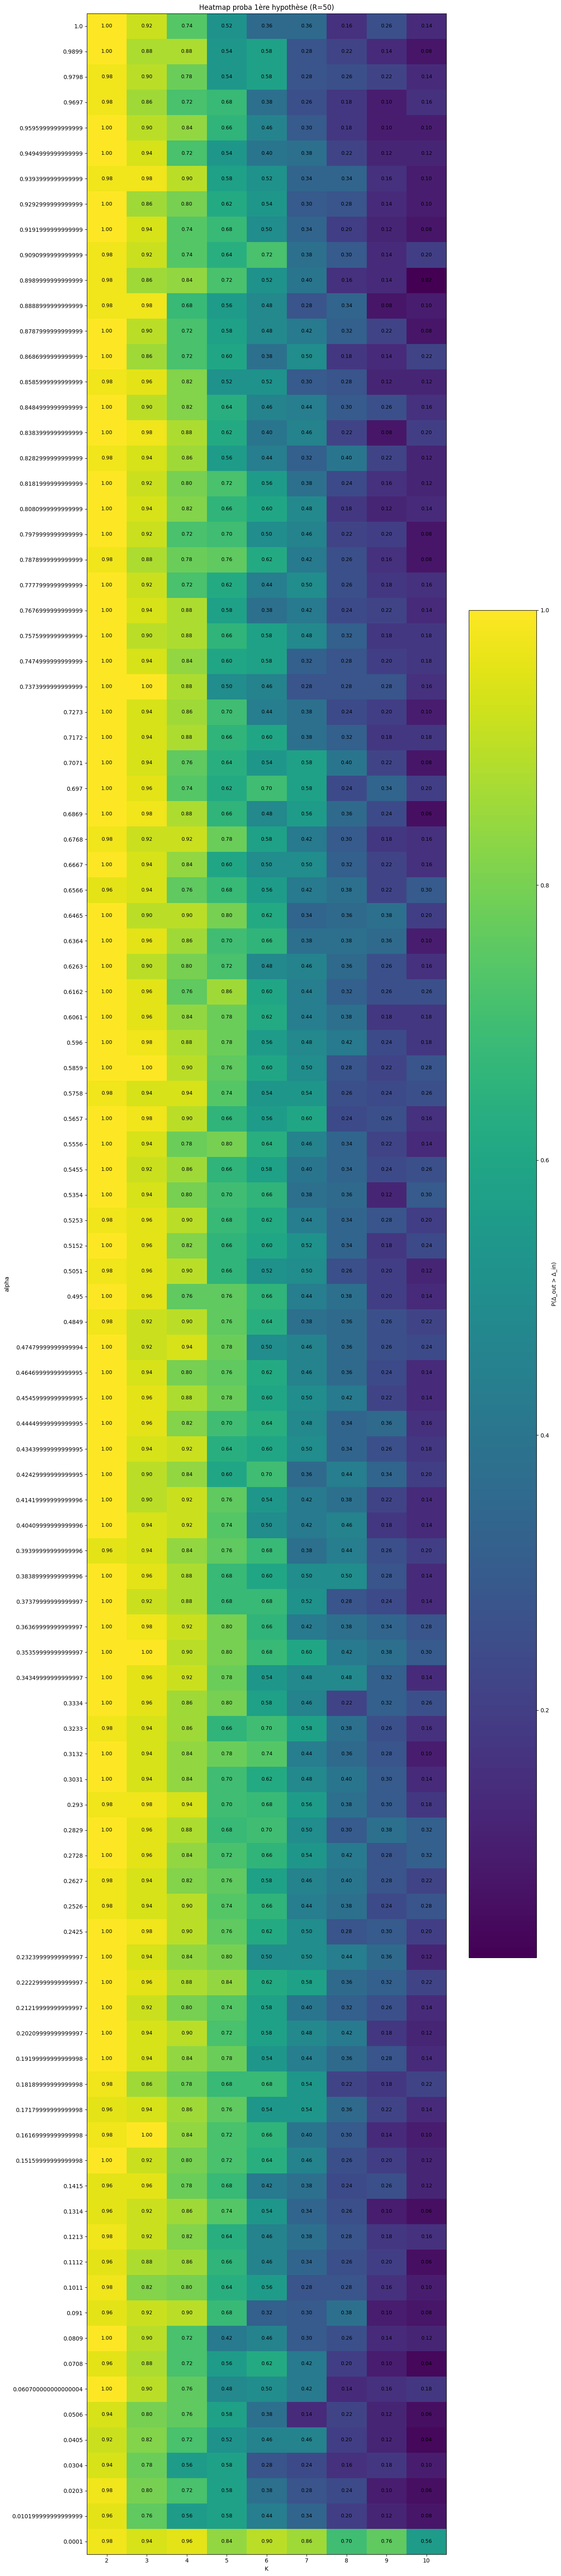

In [14]:
alphas = np.linspace(0.0001, 1, num=100)
Ks     = [2,3,4,5,6,7,8,9,10]

P = sweep_alpha_K_heatmap_mp(
    alphas=alphas,
    Ks=Ks,
    R=50,
    base_seed=123,
    n_states=5,
    order_k=1,
    n_max=1000,
    check_every=200,
    window=5,
    delta=1e-3,
    subst_method="random",
    cost=1.0,
    indel_strategy="median_nonzero",
)


In [18]:
def _one_point_prob_balance(alpha, K, R, base_seed, w_ratio, kwargs):
    ok = 0
    for r in range(R):
        out = run_one_experiment_check_hypotheses(
            K=K,
            alpha=float(alpha),
            base_seed=base_seed + 10_000 * (int(1_000 * alpha) + 1) + 1_000 * K + r,
            w_ratio=float(w_ratio),
            **kwargs
        )
        ok += int(out["check_balance"])  # Delta_out - Delta_in > w_ratio * Delta_in
    return ok / R


def sweep_alpha_K_heatmap_mp_balance(alphas, Ks, R=20, base_seed=123, w_ratio=2.0, n_jobs=-1, **kwargs):
    alphas = list(alphas)
    Ks = list(Ks)
    tasks = [(a, K) for a in alphas for K in Ks]

    probs = Parallel(
        n_jobs=n_jobs,
        backend="loky",
        batch_size="auto",
        pre_dispatch="2*n_jobs",
    )(
        delayed(_one_point_prob_balance)(a, K, R, base_seed, w_ratio, kwargs) for (a, K) in tasks
    )

    P = np.array(probs, dtype=float).reshape(len(alphas), len(Ks))

    fig, ax = plt.subplots(figsize=(1.2*len(Ks) + 3, 0.6*len(alphas) + 3))
    im = ax.imshow(P, aspect="auto", origin="lower")
    fig.colorbar(im, ax=ax, label="P(Delta_out-Delta_in > w_ratio*Delta_in)")
    ax.set_xticks(np.arange(len(Ks))); ax.set_xticklabels([str(k) for k in Ks])
    ax.set_yticks(np.arange(len(alphas))); ax.set_yticklabels([str(a) for a in alphas])
    ax.set_xlabel("K"); ax.set_ylabel("alpha")
    ax.set_title(f"Heatmap proba 2eme hypothese (R={R}, w_ratio={w_ratio})")

    for i in range(len(alphas)):
        for j in range(len(Ks)):
            ax.text(j, i, f"{P[i,j]:.2f}", ha="center", va="center", fontsize=9)


    plt.tight_layout()
    return P


In [24]:
alphas = np.linspace(0.000001, 1, num=100)
Ks     = [2,3,4,5,6,7,8,9,10]

P2 = sweep_alpha_K_heatmap_mp_balance(
    alphas=alphas,
    Ks=Ks,
    R=50,
    base_seed=123,
    w_ratio=2.0,
    n_states=5,
    order_k=1,
    n_max=1000,
    check_every=200,
    window=5,
    delta=1e-3,
    subst_method="random",
    cost=1.0,
    indel_strategy="median_nonzero",
)


KeyboardInterrupt: 

In [25]:
alphas

array([1.00000e-06, 1.01020e-02, 2.02030e-02, 3.03040e-02, 4.04050e-02,
       5.05060e-02, 6.06070e-02, 7.07080e-02, 8.08090e-02, 9.09100e-02,
       1.01011e-01, 1.11112e-01, 1.21213e-01, 1.31314e-01, 1.41415e-01,
       1.51516e-01, 1.61617e-01, 1.71718e-01, 1.81819e-01, 1.91920e-01,
       2.02021e-01, 2.12122e-01, 2.22223e-01, 2.32324e-01, 2.42425e-01,
       2.52526e-01, 2.62627e-01, 2.72728e-01, 2.82829e-01, 2.92930e-01,
       3.03031e-01, 3.13132e-01, 3.23233e-01, 3.33334e-01, 3.43435e-01,
       3.53536e-01, 3.63637e-01, 3.73738e-01, 3.83839e-01, 3.93940e-01,
       4.04041e-01, 4.14142e-01, 4.24243e-01, 4.34344e-01, 4.44445e-01,
       4.54546e-01, 4.64647e-01, 4.74748e-01, 4.84849e-01, 4.94950e-01,
       5.05051e-01, 5.15152e-01, 5.25253e-01, 5.35354e-01, 5.45455e-01,
       5.55556e-01, 5.65657e-01, 5.75758e-01, 5.85859e-01, 5.95960e-01,
       6.06061e-01, 6.16162e-01, 6.26263e-01, 6.36364e-01, 6.46465e-01,
       6.56566e-01, 6.66667e-01, 6.76768e-01, 6.86869e-01, 6.969